##Overall Analysis

Radar Graph

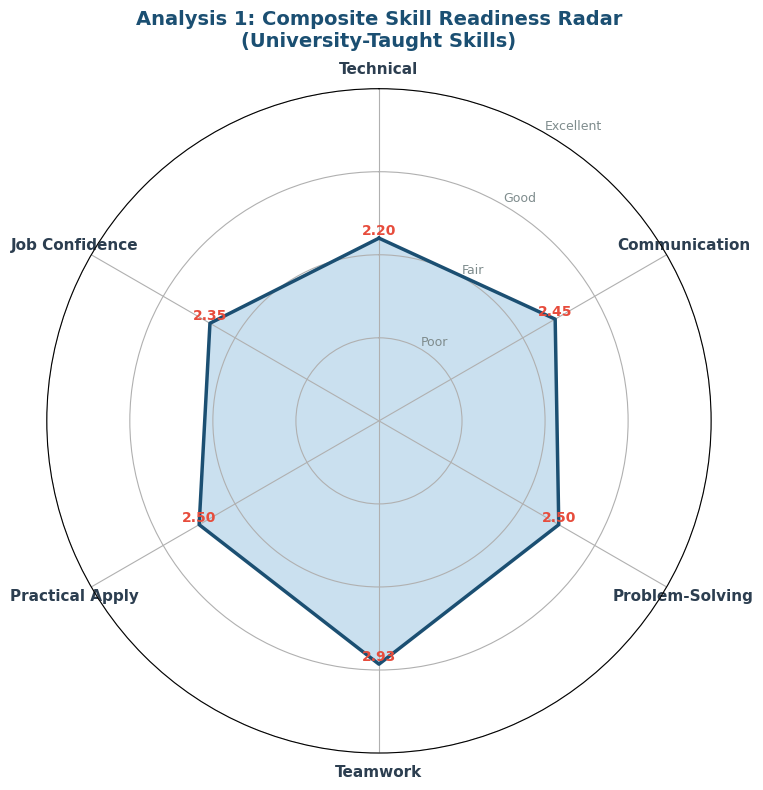

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. DATA LOADING (Dono platforms ke liye universal handle)
try:
    df = dataset # Power BI automatically uses 'dataset'
except NameError:
    # Google Colab ke liye file name yahan likhein
    df = pd.read_excel('FJWU_Data_Fixed_Final.xlsx')

# 2. CONFIGURATION
RATING_MAP = {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4}

# Power BI mein columns isi order mein select karein:
rating_cols = [
    'Rate according to the following (Learning from University): [TECHNICAL skills relevant to your field]',
    'Rate according to the following (Learning from University): [COMMUNICATION skills]',
    'Rate according to the following (Learning from University): [PROBLEM-SOLVING ability]',
    'Rate according to the following (Learning from University): [TEAMWORK Skills]',
    'Rate according to the following (Learning from University): [Ability to APPLY knowledge in real-world situations]',
    'Rate according to the following (Learning from University): [How confident are you in getting a job after graduation?]'
]

# Labels for the Radar
categories = ['Technical', 'Communication', 'Problem-Solving', 'Teamwork', 'Practical Apply', 'Job Confidence']

# Values calculate karna
values = []
for col in rating_cols:
    if col in df.columns:
        numeric = df[col].map(RATING_MAP).dropna()
        values.append(round(numeric.mean(), 2) if not numeric.empty else 0)
    else:
        values.append(0)

# Radar chart close karne ke liye data repeat karna
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

# 3. PLOTTING (Exact Image 1 Style)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Design Elements
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Labels (X-axis)
plt.xticks(angles[:-1], categories, color='#2C3E50', size=11, fontweight='bold')

# Grids (Y-axis)
ax.set_rlabel_position(30)
plt.yticks([1, 2, 3, 4], ["Poor", "Fair", "Good", "Excellent"], color="#7F8C8D", size=9)
plt.ylim(0, 4)

# Plot Line aur Fill (Blue Theme)
ax.plot(angles, values, color='#1B4F72', linewidth=2.5, linestyle='solid')
ax.fill(angles, values, color='#2E86C1', alpha=0.25)

# Annotations (Points par scores likhna - Red/Orange color)
for i in range(N):
    ax.annotate(f"{values[i]:.2f}", xy=(angles[i], values[i]),
                fontsize=10, fontweight='bold', color="#E74C3C",
                ha="center", va="bottom")

# Title
plt.title("Analysis 1: Composite Skill Readiness Radar\n(University-Taught Skills)",
          fontsize=14, fontweight="bold", pad=30, color="#1B4F72")

plt.tight_layout()
plt.show()

Overall Readiness Analysis

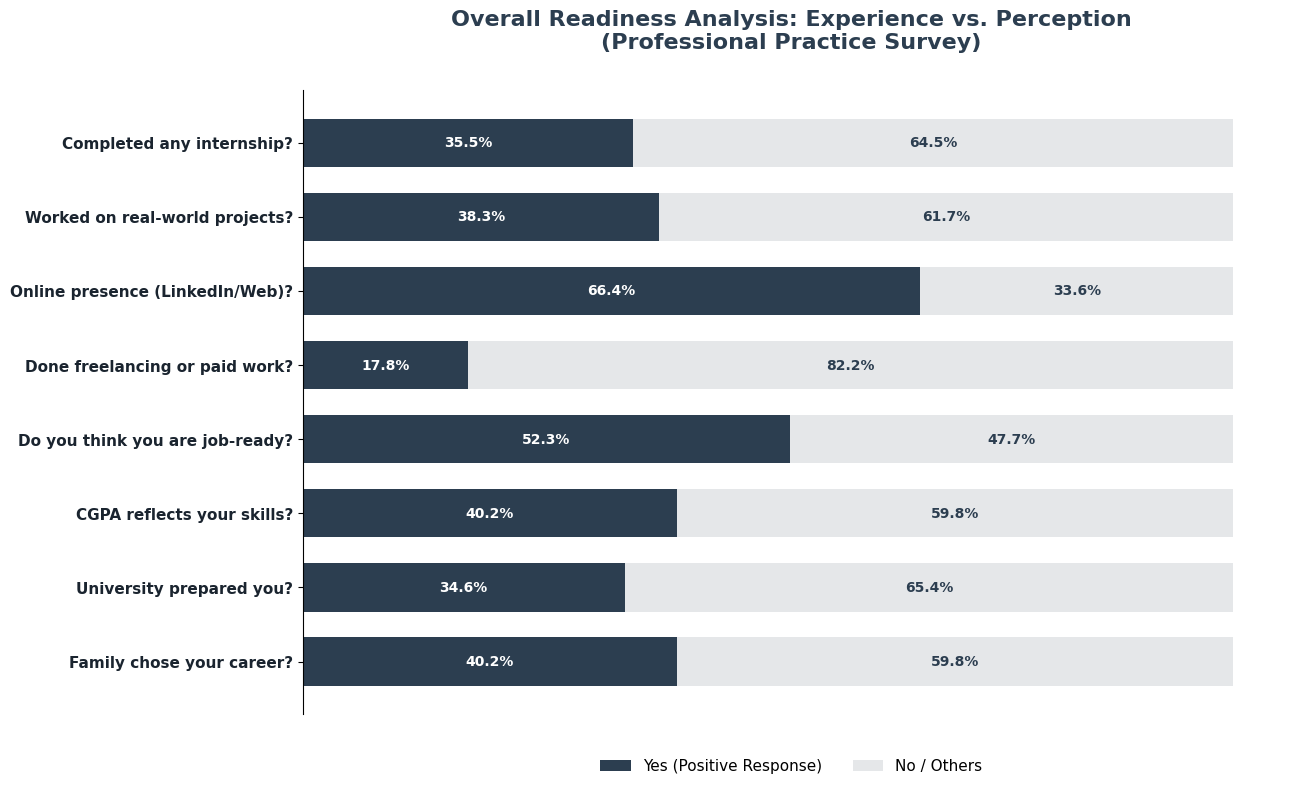

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. DATA LOADING (Handles Power BI and Colab)
try:
    df = dataset # Power BI automatic variable
except NameError:
    # Colab: Looks for your uploaded CSV or Excel file
    file_csv = 'FJWU_Data_Fixed_Final (2).xlsx - Sheet1.csv'
    if os.path.exists(file_csv):
        df = pd.read_csv(file_csv)
    else:
        # Change this to your exact filename if it differs
        df = pd.read_excel('FJWU_Data_Fixed_Final.xlsx')

# 2. CONFIGURATION: Short Titles and Keywords
# These keywords help the code find the long column names automatically
analysis_map = {
    "Completed any internship?": "internship",
    "Worked on real-world projects?": "real-world projects",
    "Online presence (LinkedIn/Web)?": "online presence",
    "Done freelancing or paid work?": "freelancing",
    "Do you think you are job-ready?": "job-ready",
    "CGPA reflects your skills?": "CGPA truly reflects",
    "University prepared you?": "prepared you for industry",
    "Family chose your career?": "family wants"
}

# 3. DYNAMIC COLUMN MAPPING & CALCULATION
questions = []
yes_vals = []
no_vals = []

for display_name, keyword in analysis_map.items():
    # Find the full column name that contains the keyword
    col = next((c for c in df.columns if keyword.lower() in c.lower()), None)

    if col:
        # Clean data: count 'yes' entries (case-insensitive)
        temp_series = df[col].astype(str).str.strip().str.lower()
        total = len(temp_series)

        # Matches 'yes' or 'yes, ...'
        yes_count = temp_series.apply(lambda x: 1 if x.startswith('yes') else 0).sum()
        yes_pct = (yes_count / total) * 100

        questions.append(display_name)
        yes_vals.append(yes_pct)
        no_vals.append(100 - yes_pct)

# 4. PLOTTING (Exact Style Match)
fig, ax = plt.subplots(figsize=(13, 8))
y_pos = np.arange(len(questions))

color_yes = '#2C3E50' # Dark Slate (Yes)
color_no = '#E5E7E9'  # Light Gray (No/Other)

# Horizontal Stacked Bars
ax.barh(y_pos, yes_vals, label='Yes (Positive Response)', color=color_yes, height=0.65)
ax.barh(y_pos, no_vals, left=yes_vals, label='No / Others', color=color_no, height=0.65)

# Axis labels and Order
ax.set_yticks(y_pos)
ax.set_yticklabels(questions, fontweight='bold', fontsize=11, color='#1A242F')
ax.invert_yaxis()

# Add Percentage Labels inside/on bars
for i in range(len(questions)):
    if yes_vals[i] > 5:
        ax.text(yes_vals[i]/2, i, f"{yes_vals[i]:.1f}%", va='center', ha='center',
                color='white', fontweight='bold', fontsize=10)
    if no_vals[i] > 5:
        ax.text(yes_vals[i] + (no_vals[i]/2), i, f"{no_vals[i]:.1f}%", va='center', ha='center',
                color='#2C3E50', fontweight='bold', fontsize=10)

# Final Styling
ax.set_title('Overall Readiness Analysis: Experience vs. Perception\n(Professional Practice Survey)',
             fontsize=16, fontweight='bold', pad=30, color='#2C3E50')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=11)

# Remove clutter
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.get_xaxis().set_visible(False)

plt.tight_layout()
plt.show()

Semester Wise Progress

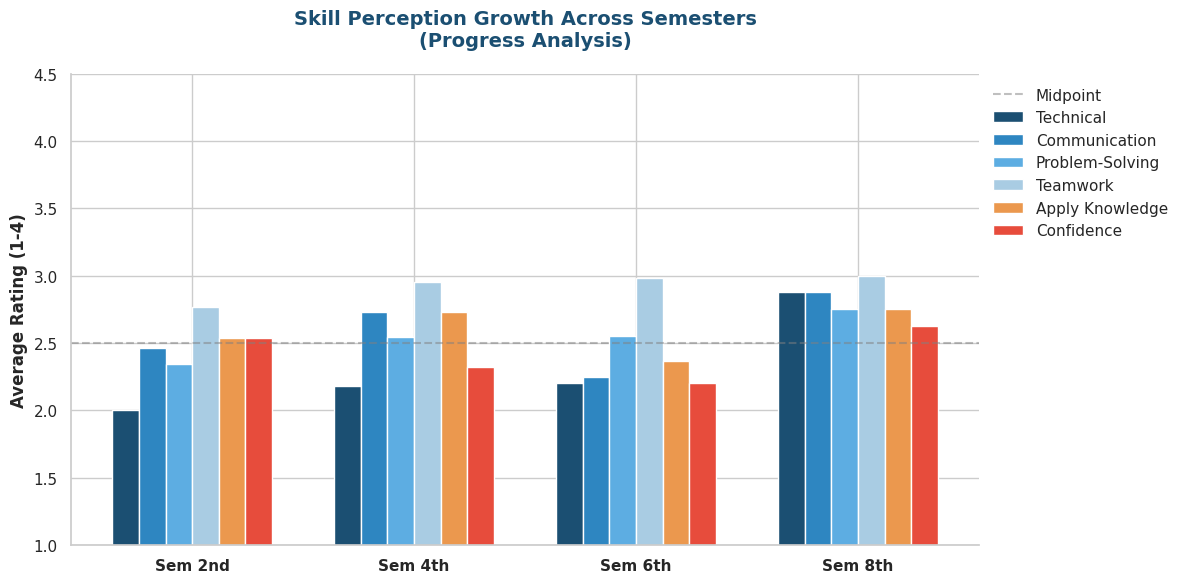

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. DATA LOADING
try:
    df = dataset  # Power BI Mode
except NameError:
    # Colab Mode: File name check karlein (FJWU_Data_Fixed_Final (2).xlsx - Sheet1.csv)
    file_path = 'FJWU_Data_Fixed_Final (2).xlsx - Sheet1.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
    else:
        # Agar Excel file hai toh usay read karega
        df = pd.read_excel('FJWU_Data_Fixed_Final.xlsx')

# 2. CONFIGURATION
RATING_MAP = {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4}
SEM_ORDER = ["2nd", "4th", "6th", "8th"]
COLORS = ["#1B4F72", "#2E86C1", "#5DADE2", "#A9CCE3", "#EB984E", "#E74C3C"]

# Yeh keywords aapke exact sawalon se liye gaye hain
KEYWORDS = {
    "TECHNICAL": "Technical",
    "COMMUNICATION": "Communication",
    "PROBLEM-SOLVING": "Problem-Solving",
    "TEAMWORK": "Teamwork",
    "APPLY": "Apply Knowledge",
    "confident": "Confidence"
}

# 3. ROBUST DATA PROCESSING
df2 = df.copy()

# Semester Column dhoondna (Spaces ignore karne ke liye)
sem_col = next((c for c in df2.columns if "semester" in c.lower()), None)

if sem_col:
    # Data standardizing
    df2[sem_col] = df2[sem_col].astype(str).str.strip()
    df2 = df2[df2[sem_col].isin(SEM_ORDER)]

    mapped_labels = []
    # Keywords ke zariye columns dhoondna
    for key, label in KEYWORDS.items():
        # Column search (Case insensitive)
        target = next((c for c in df2.columns if key.lower() in c.lower()), None)
        if target:
            # Power BI data forced to numeric
            df2[label] = pd.to_numeric(df2[target].map(RATING_MAP), errors='coerce')
            mapped_labels.append(label)

    # Average calculate karna (Semesters ko order mein lana)
    avg_data = df2.groupby(sem_col)[mapped_labels].mean().reindex(SEM_ORDER).dropna(how='all')

    # 4. PLOTTING
    if not avg_data.empty:
        x = np.arange(len(avg_data.index))
        width = 0.12
        fig, ax = plt.subplots(figsize=(12, 6))

        for i, skill in enumerate(mapped_labels):
            offset = (i - len(mapped_labels) / 2) * width + width / 2
            ax.bar(x + offset, avg_data[skill], width, label=skill, color=COLORS[i % len(COLORS)])

        # Final Formatting
        ax.set_xticks(x)
        ax.set_xticklabels([f"Sem {s}" for s in avg_data.index], fontweight='bold')
        ax.set_ylabel("Average Rating (1-4)", fontweight='bold')
        ax.set_ylim(1, 4.5)
        ax.axhline(2.5, color="grey", linestyle="--", alpha=0.5, label="Midpoint")

        ax.set_title("Skill Perception Growth Across Semesters\n(Progress Analysis)",
                     fontsize=14, fontweight="bold", pad=20, color="#1B4F72")

        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()
    else:
        print("Data Error: Filtered dataset is empty. Check your Semester values.")
else:
    print("Column Error: 'Current Semester' column not found.")

Weaknesses

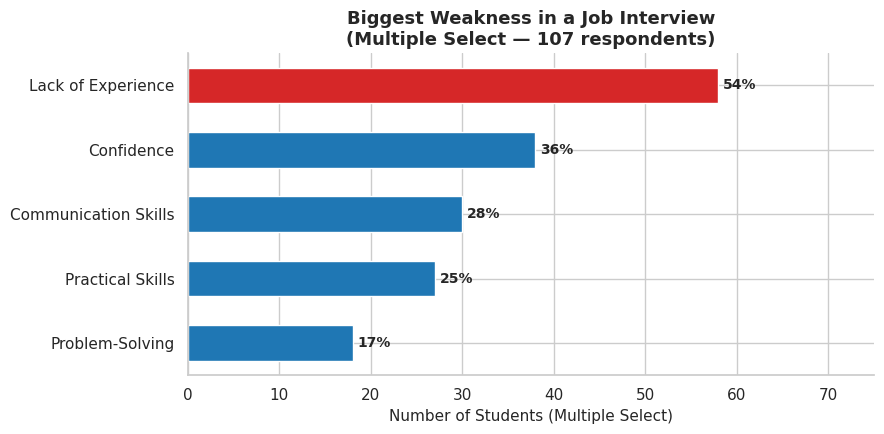

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data setup
weakness_data = {
    "Lack of Experience" : 58,
    "Confidence"         : 38,
    "Communication Skills": 30,
    "Practical Skills"   : 27,
    "Problem-Solving"    : 18,
}

# Colors (Assuming C3 is your highlight color and C2 is the base)
C3 = "#d62728" # Red/Highlight
C2 = "#1f77b4" # Blue/Standard

wdf = pd.Series(weakness_data).sort_values()
colors = [C3 if v == max(weakness_data.values()) else C2 for v in wdf.values]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(wdf.index, wdf.values, color=colors, edgecolor="white", height=0.55)

# Adding labels: Removed the bar.get_width() numbering before the percentage
for bar in bars:
    percentage = (bar.get_width() / 107) * 100
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{percentage:.0f}%", # Show only percentage
            va="center", fontsize=10, fontweight="bold")

# Formatting
ax.set_xlabel("Number of Students (Multiple Select)", fontsize=11)
# Removed "Chart 2:" from the title
ax.set_title("Biggest Weakness in a Job Interview\n(Multiple Select — 107 respondents)",
             fontsize=13, fontweight="bold")

ax.set_xlim(0, 75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("weaknesses_analysis.png", bbox_inches="tight")
plt.show()

Tudent Perception

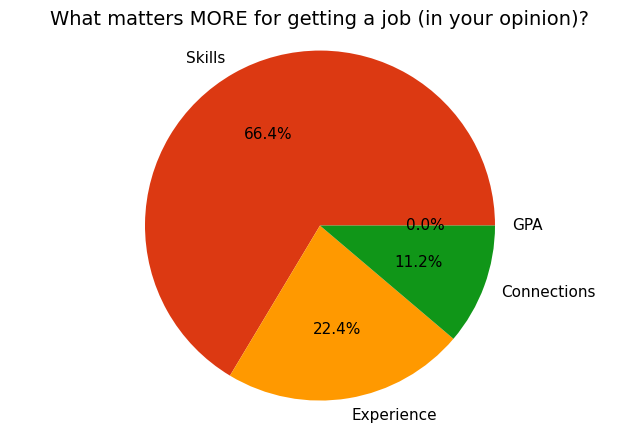

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = ['GPA', 'Skills', 'Experience', 'Connections']
sizes = [0, 66.4, 22.4, 11.2]

# Colors similar to Google Forms
colors = ['#3366CC', '#DC3912', '#FF9900', '#109618']

# Create figure
plt.figure(figsize=(8, 5))

# Pie chart
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=0,
    textprops={'fontsize': 11}
)

# Title
plt.title('What matters MORE for getting a job (in your opinion)?',
          fontsize=14)

# Equal aspect ratio ensures circle shape
plt.axis('equal')

# Show chart
plt.show()

Analytical Growth

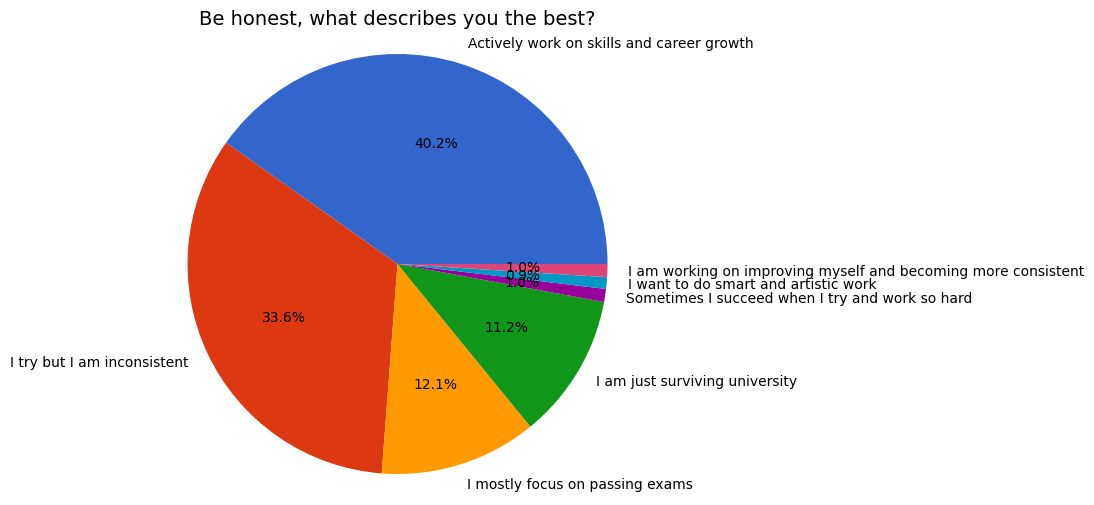

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = [
    'Actively work on skills and career growth',
    'I try but I am inconsistent',
    'I mostly focus on passing exams',
    'I am just surviving university',
    'Sometimes I succeed when I try and work so hard',
    'I want to do smart and artistic work',
    'I am working on improving myself and becoming more consistent'
]

sizes = [40.2, 33.6, 12.1, 11.2, 1.0, 0.9, 1.0]

# Google Forms-like colors
colors = [
    '#3366CC',  # Blue
    '#DC3912',  # Red
    '#FF9900',  # Orange
    '#109618',  # Green
    '#990099',  # Purple
    '#0099C6',  # Cyan
    '#DD4477'   # Pink
]

# Create figure
plt.figure(figsize=(10, 6))

# Pie chart
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=0,
    textprops={'fontsize': 10}
)

# Title
plt.title(
    'Be honest, what describes you the best?',
    fontsize=14
)

# Keep pie chart circular
plt.axis('equal')

# Show chart
plt.show()

##Competency Rating

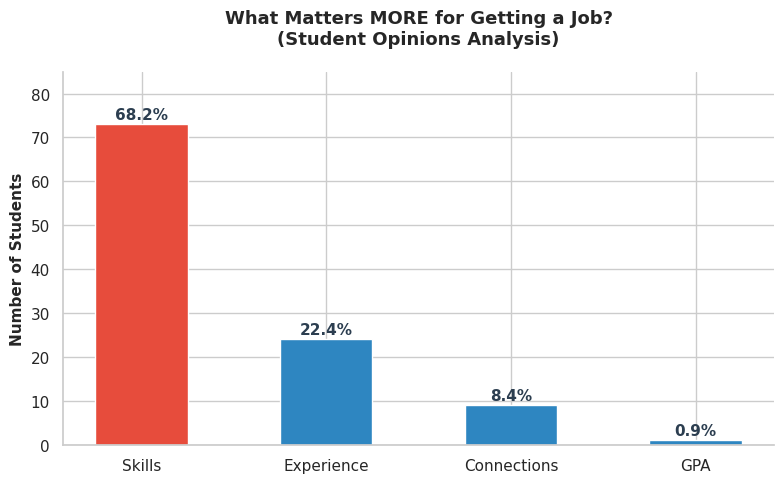

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# 1. DATA LOADING (Dono platforms ke liye)
try:
    df = dataset # Power BI mode
except NameError:
    df = pd.read_excel('FJWU_Data_Fixed_Final.xlsx') # Colab mode

# 2. CONFIGURATION
col = "What matters MORE for getting a job (in your opinion)? "
C2 = "#2E86C1" # Original Blue
C3 = "#E74C3C" # Original Red (Highlight)

if col in df.columns:
    counts = df[col].value_counts()
    total = len(df)

    # Labels ko wrap karna taake Power BI mein cut na hon
    wrapped_labels = [textwrap.fill(label, width=15) for label in counts.index]

    # 3. PLOTTING
    fig, ax = plt.subplots(figsize=(8, 5))

    # Bars logic
    bars = ax.bar(wrapped_labels, counts.values,
                  color=[C3 if v == counts.max() else C2 for v in counts.values],
                  edgecolor="white", width=0.5)

    # Sirf Percentage dikhane ke liye (Numbers remove kar diye hain)
    for bar in bars:
        height = bar.get_height()
        pct = (height / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f"{pct:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold", color="#2C3E50")

    # Title & Labels (No Numbering)
    ax.set_ylabel("Number of Students", fontsize=11, fontweight='bold')
    ax.set_title("What Matters MORE for Getting a Job?\n(Student Opinions Analysis)",
                 fontsize=13, fontweight="bold", pad=20)

    # Design adjustments
    ax.set_ylim(0, max(counts.values) + 12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found. Please check column selection in Power BI.")